Importing Libraries 

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Styling the Theme

In [7]:
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)

Loading data sets 

In [8]:
data_path = "../Data"

demo = pd.read_csv(f"{data_path}/df_final_demo_cleaned.csv")
exp = pd.read_csv(f"{data_path}/df_final_experiment_clients_cleaned.csv")
web = pd.read_csv(f"{data_path}/final_test_data.csv")
funnel = pd.read_csv(f"{data_path}/web_funnel_sorted.csv")

print("demo:", demo.shape)
print("exp:", exp.shape)
print("web:", web.shape)
print("funnel:", funnel.shape)

demo: (70609, 9)
exp: (70609, 2)
web: (443897, 7)
funnel: (744641, 6)


 Merge the two cleaned datasets

In [9]:
print(demo.columns)
print(exp.columns)

Index(['client_id', 'tenure_years', 'tenure_months', 'age', 'gender',
       'num_accts', 'balance', 'calls_last_6_months', 'logons_last_6_months'],
      dtype='str')
Index(['client_id', 'group_test'], dtype='str')


In [13]:
df_final = demo.merge(
    exp,
    on="client_id",
    how="left"
)

df_final = df_final.dropna(subset=["group_test"])
df_final = df_final.reset_index(drop=True)

print(df_final.head())
print(df_final["group_test"].value_counts())

   client_id  tenure_years  tenure_months   age gender  num_accts    balance  \
0     836976           6.0           73.0  60.5      U        2.0   45105.30   
1    2304905           7.0           94.0  58.0      U        2.0  110860.30   
2    1439522           5.0           64.0  32.0      U        2.0   52467.79   
3    1562045          16.0          198.0  49.0      M        2.0   67454.65   
4    5126305          12.0          145.0  33.0      F        2.0  103671.75   

   calls_last_6_months  logons_last_6_months group_test  
0                  6.0                   9.0       test  
1                  6.0                   9.0    control  
2                  6.0                   9.0       test  
3                  3.0                   6.0       test  
4                  0.0                   3.0    control  
group_test
test       26968
control    23532
Name: count, dtype: int64


Droping rows where group_test is null

In [14]:
 
df_final = df_final.dropna(subset=["group_test"])





keep only valid rows and reset index

In [15]:
df_final = df_final.reset_index(drop=True)

Quick Confirmation

In [16]:
for name, df in [("demo", demo), ("exp", exp), ("web", web)]:
    print(f"\n── {name} ──")
    print(df.shape)
    print(df.dtypes)
    print(df.head(2))


── demo ──
(70609, 9)
client_id                 int64
tenure_years            float64
tenure_months           float64
age                     float64
gender                      str
num_accts               float64
balance                 float64
calls_last_6_months     float64
logons_last_6_months    float64
dtype: object
   client_id  tenure_years  tenure_months   age gender  num_accts   balance  \
0     836976           6.0           73.0  60.5      U        2.0   45105.3   
1    2304905           7.0           94.0  58.0      U        2.0  110860.3   

   calls_last_6_months  logons_last_6_months  
0                  6.0                   9.0  
1                  6.0                   9.0  

── exp ──
(70609, 2)
client_id     int64
group_test      str
dtype: object
   client_id group_test
0    9988021       test
1    8320017       test

── web ──
(443897, 7)
client_id       int64
visitor_id        str
visit_id          str
process_step      str
date_time         str
source         

Merging Demo + Experiment
figuring  out which clients are in Test vs Control 

In [17]:
print(demo.columns)
print(exp.columns)
print(df.columns)

Index(['client_id', 'tenure_years', 'tenure_months', 'age', 'gender',
       'num_accts', 'balance', 'calls_last_6_months', 'logons_last_6_months'],
      dtype='str')
Index(['client_id', 'group_test'], dtype='str')
Index(['client_id', 'visitor_id', 'visit_id', 'process_step', 'date_time',
       'source', 'group_test'],
      dtype='str')


In [18]:
df = demo.merge(exp, on="client_id", how="inner")

print(f"Merged shape: {df.shape}")
print(df["group_test"].value_counts())

Merged shape: (70609, 10)
group_test
test       26968
control    23532
Name: count, dtype: int64


DEMOGRAPHICS: figuring  out who the primary clients are ?

Checking Columns

In [19]:
print(df.columns)

Index(['client_id', 'tenure_years', 'tenure_months', 'age', 'gender',
       'num_accts', 'balance', 'calls_last_6_months', 'logons_last_6_months',
       'group_test'],
      dtype='str')


 Age Distribution

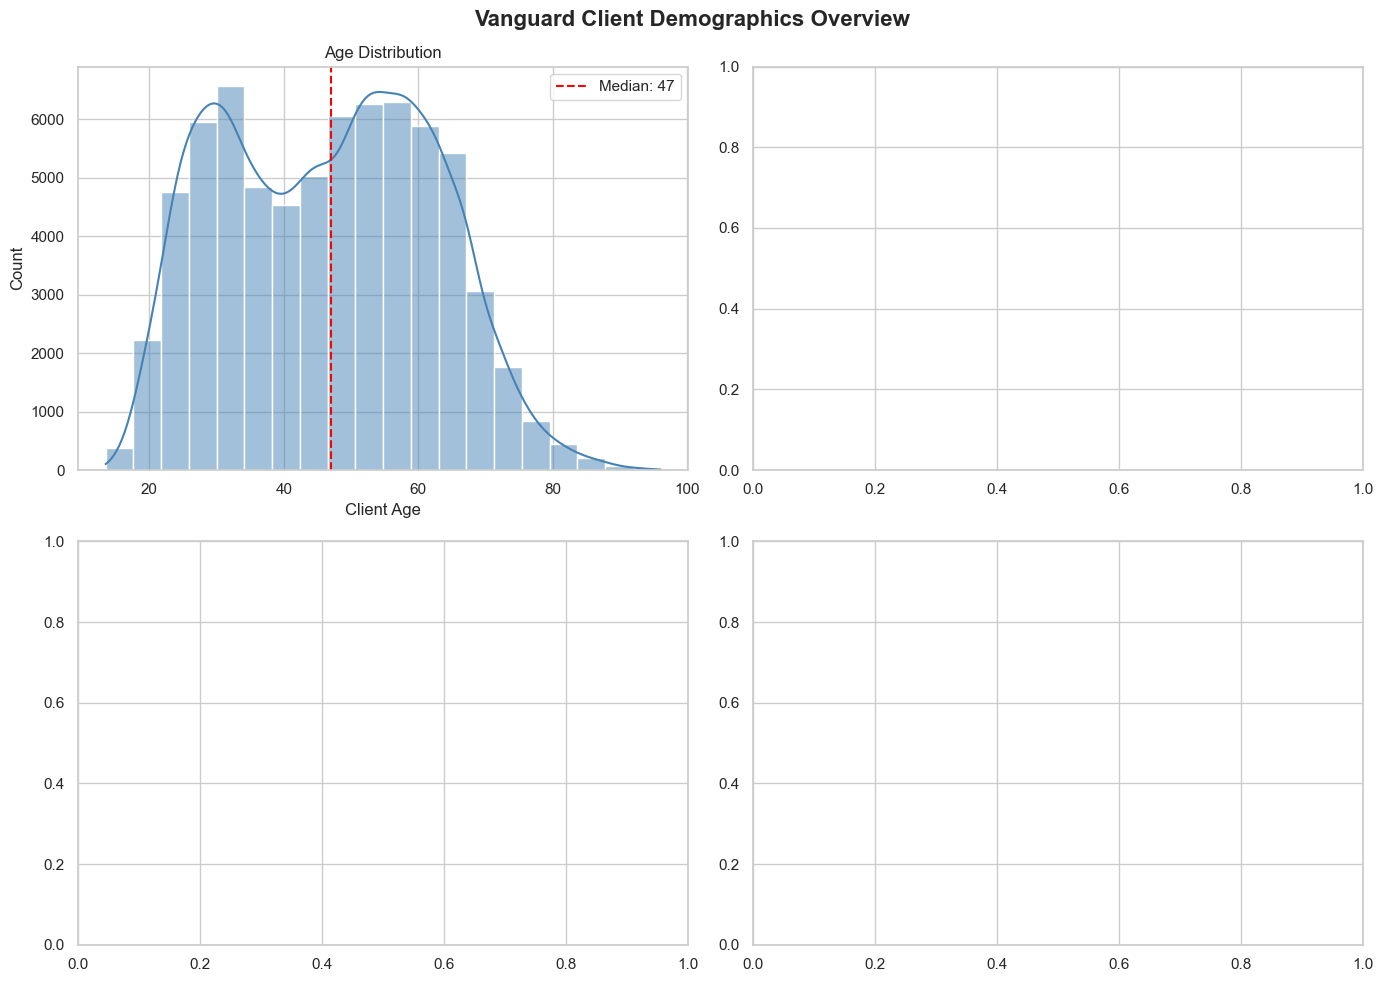

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Vanguard Client Demographics Overview", fontsize=16, fontweight="bold")

sns.histplot(df["age"].dropna(), bins=20, kde=True, ax=axes[0, 0], color="steelblue")
axes[0, 0].set_title("Age Distribution")
axes[0, 0].set_xlabel("Client Age")
axes[0, 0].axvline(df["age"].median(), color="red", linestyle="--",
                   label=f"Median: {df['age'].median():.0f}")
axes[0, 0].legend()

plt.tight_layout()
plt.show()

Gender Distribution

C:\Users\Desmond\AppData\Local\Temp\ipykernel_10652\2139699849.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


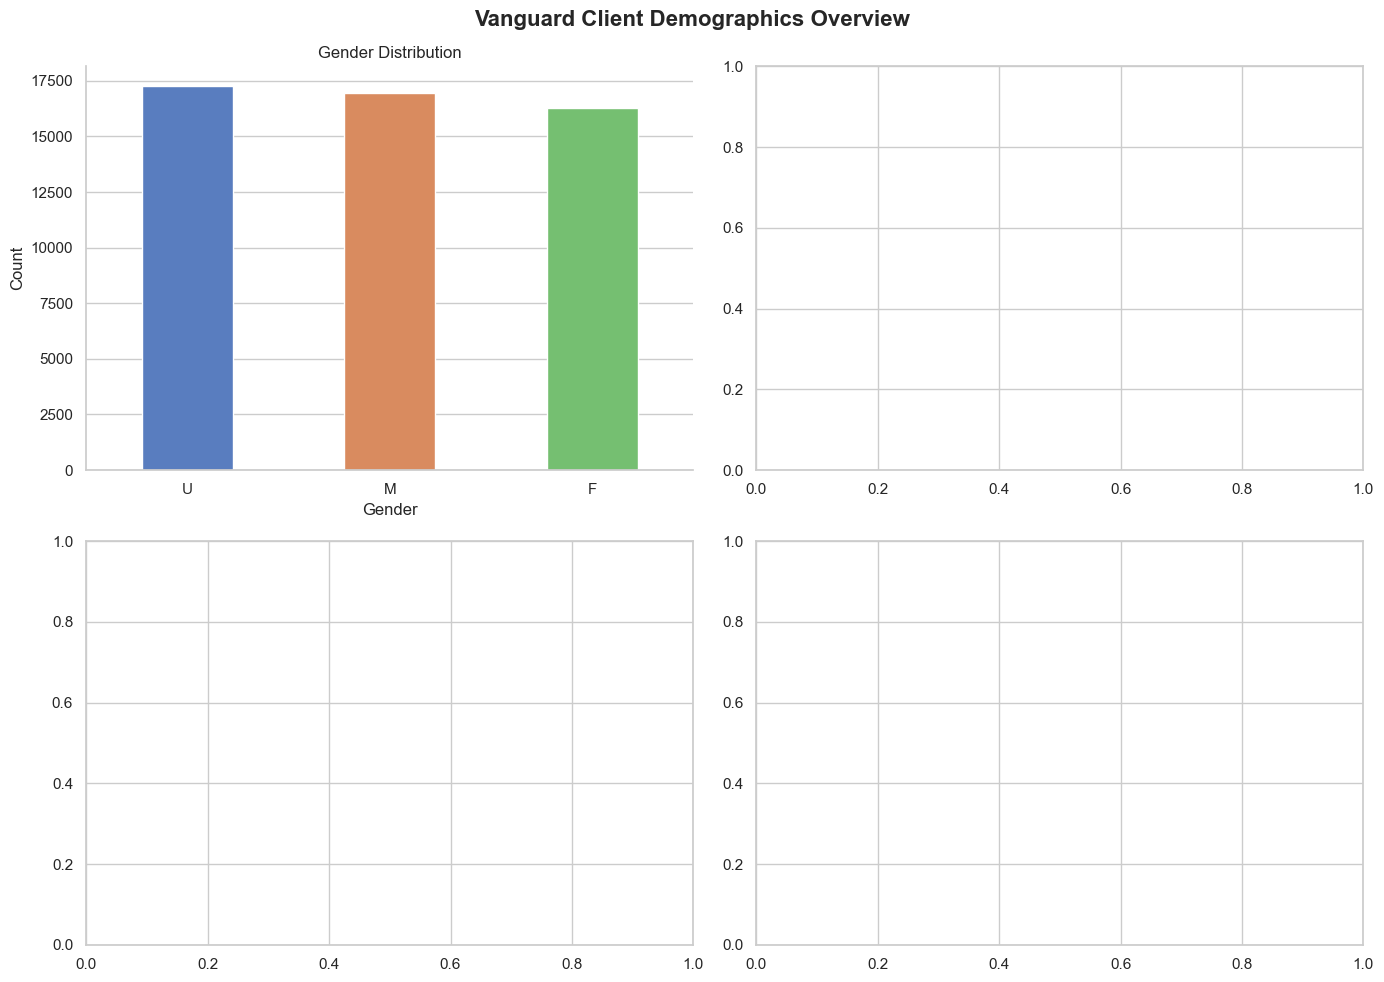

In [79]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

gender_counts = df_final["gender"].value_counts().reset_index()
gender_counts.columns = ["gender", "count"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Vanguard Client Demographics Overview", fontsize=16, fontweight="bold")

muted_colors = sns.color_palette("muted", len(gender_counts))

sns.barplot(
    data=gender_counts,
    x="gender",
    y="count",
    ax=axes[0, 0],
    palette=muted_colors,
    edgecolor="white",
    linewidth=1.0,
    width=0.45
)

axes[0, 0].set_title("Gender Distribution")
axes[0, 0].set_xlabel("Gender")
axes[0, 0].set_ylabel("Count")

for spine in ["top", "right"]:
    axes[0, 0].spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

In [77]:
print(df_final.columns)
print(df_final["gender"].value_counts())

Index(['client_id', 'tenure_years', 'tenure_months', 'age', 'gender',
       'num_accts', 'balance', 'calls_last_6_months', 'logons_last_6_months',
       'group_test'],
      dtype='str')
gender
U    17282
M    16947
F    16259
Name: count, dtype: int64


Account Balance Distirbution

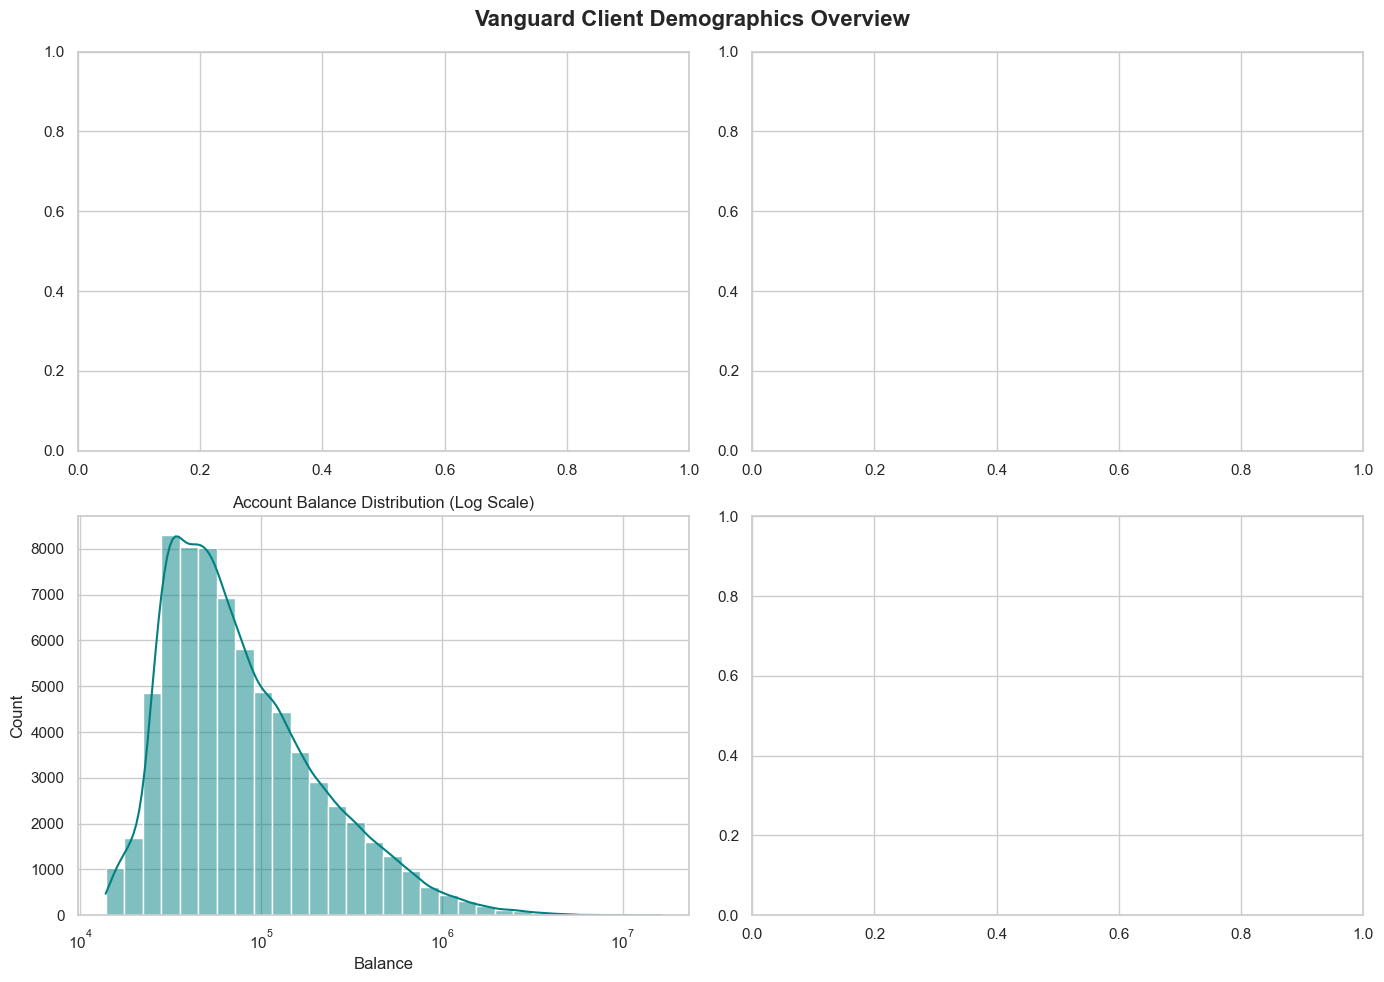

In [78]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Vanguard Client Demographics Overview", fontsize=16, fontweight="bold")

sns.histplot(
    df["balance"].dropna(),
    bins=30,
    kde=True,
    ax=axes[1, 0],
    color="teal",
    log_scale=(True, False)
)

axes[1, 0].set_title("Account Balance Distribution (Log Scale)")
axes[1, 0].set_xlabel("Balance")
axes[1, 0].set_ylabel("Count")

plt.tight_layout()
plt.show()

Number of Accoutns Distribution

C:\Users\Desmond\AppData\Local\Temp\ipykernel_10652\3007596598.py:8: UserWarning: 
The palette list has fewer values (4) than needed (8) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(


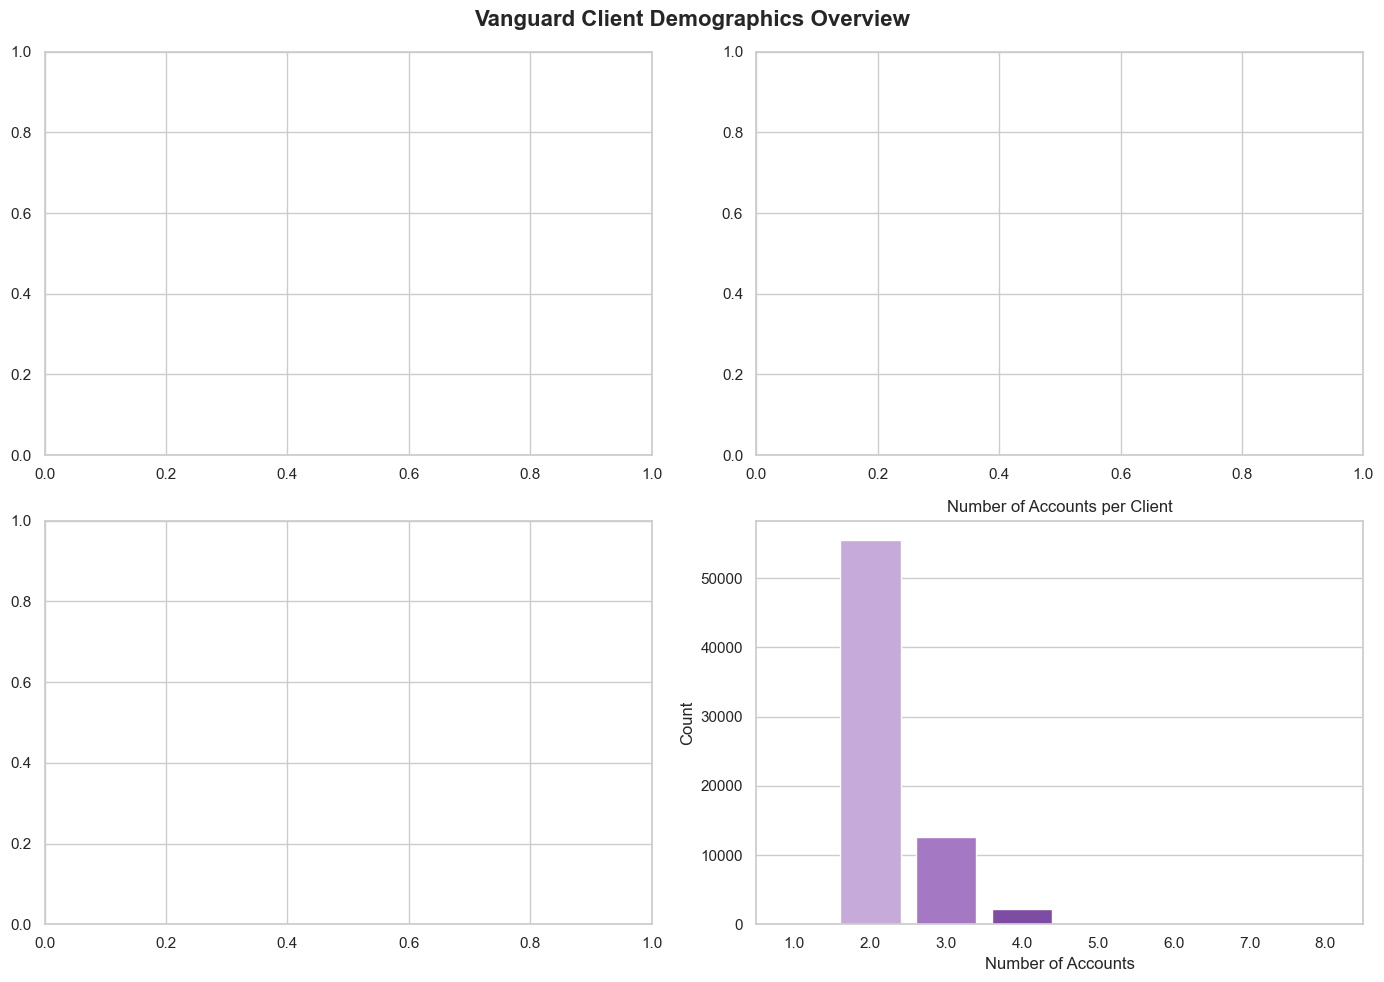

In [73]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Vanguard Client Demographics Overview", fontsize=16, fontweight="bold")

acct_counts = df["num_accts"].value_counts().sort_index()

purple_palette = ["#E6DAF7", "#C8A2E2", "#A76BCF", "#7E3FB2"]

sns.barplot(
    x=acct_counts.index.astype(str),
    y=acct_counts.values,
    ax=axes[1, 1],
    hue=acct_counts.index.astype(str),
    palette=purple_palette,
    legend=False,
    dodge=False
)

axes[1, 1].set_title("Number of Accounts per Client")
axes[1, 1].set_xlabel("Number of Accounts")
axes[1, 1].set_ylabel("Count")

plt.tight_layout()
plt.show()

All elements Together 

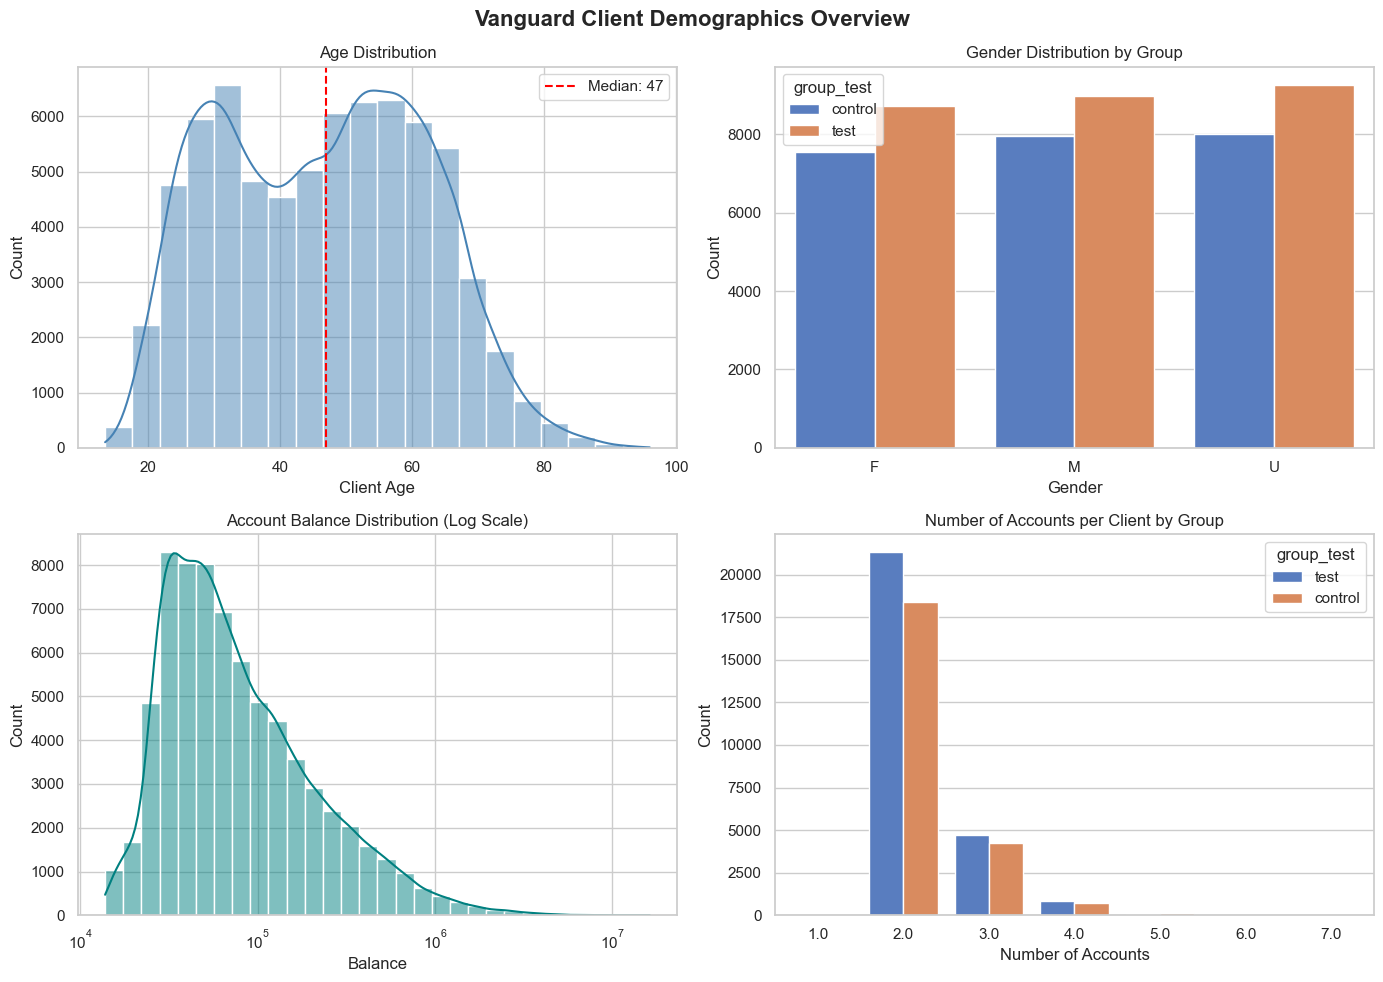

In [45]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Vanguard Client Demographics Overview", fontsize=16, fontweight="bold")

# Age Distribution
sns.histplot(
    df["age"].dropna(),
    bins=20,
    kde=True,
    ax=axes[0, 0],
    color="steelblue"
)
axes[0, 0].set_title("Age Distribution")
axes[0, 0].set_xlabel("Client Age")
axes[0, 0].axvline(
    df["age"].median(),
    color="red",
    linestyle="--",
    label=f"Median: {df['age'].median():.0f}"
)
axes[0, 0].legend()

# Gender Distribution by Group
gender_counts = (
    df.groupby(["gender", "group_test"])
      .size()
      .reset_index(name="count")
)

sns.barplot(
    data=gender_counts,
    x="gender",
    y="count",
    hue="group_test",
    ax=axes[0, 1],
    palette="muted"
)
axes[0, 1].set_title("Gender Distribution by Group")
axes[0, 1].set_xlabel("Gender")
axes[0, 1].set_ylabel("Count")

# Account Balance Distribution
sns.histplot(
    df["balance"].dropna(),
    bins=30,
    kde=True,
    ax=axes[1, 0],
    color="teal",
    log_scale=(True, False)
)
axes[1, 0].set_title("Account Balance Distribution (Log Scale)")
axes[1, 0].set_xlabel("Balance")
axes[1, 0].set_ylabel("Count")

# Number of Accounts by Group
acct_counts = (
    df.groupby(["num_accts", "group_test"])
      .size()
      .reset_index(name="count")
)

sns.barplot(
    data=acct_counts,
    x="num_accts",
    y="count",
    hue="group_test",
    ax=axes[1, 1],
    palette="muted"
)
axes[1, 1].set_title("Number of Accounts per Client by Group")
axes[1, 1].set_xlabel("Number of Accounts")
axes[1, 1].set_ylabel("Count")

plt.tight_layout()
plt.show()

C:\Users\Desmond\AppData\Local\Temp\ipykernel_10652\1752432308.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


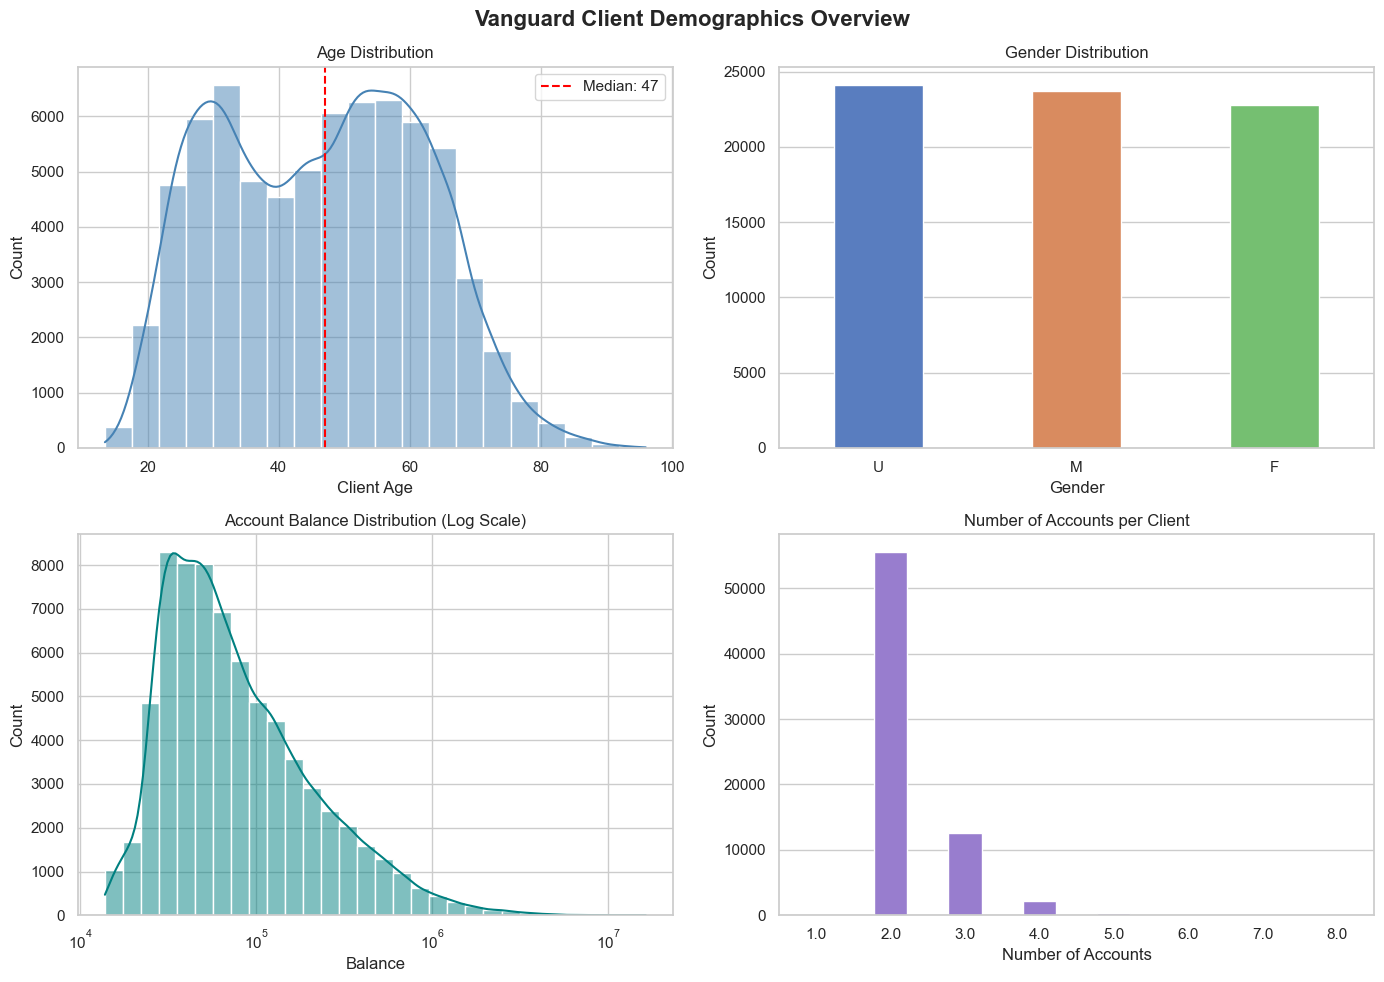

In [49]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Vanguard Client Demographics Overview", fontsize=16, fontweight="bold")

# Age Distribution
sns.histplot(
    df["age"].dropna(),
    bins=20,
    kde=True,
    ax=axes[0, 0],
    color="steelblue"
)
axes[0, 0].set_title("Age Distribution")
axes[0, 0].set_xlabel("Client Age")
axes[0, 0].set_ylabel("Count")
axes[0, 0].axvline(
    df["age"].median(),
    color="red",
    linestyle="--",
    linewidth=1.5,
    label=f"Median: {df['age'].median():.0f}"
)
axes[0, 0].legend()

# Gender Distribution
gender_counts = df["gender"].value_counts().reset_index()
gender_counts.columns = ["gender", "count"]

sns.barplot(
    data=gender_counts,
    x="gender",
    y="count",
    ax=axes[0, 1],
    palette="muted",
    width=0.45
)
axes[0, 1].set_title("Gender Distribution")
axes[0, 1].set_xlabel("Gender")
axes[0, 1].set_ylabel("Count")

# Account Balance Distribution
sns.histplot(
    df["balance"].dropna(),
    bins=30,
    kde=True,
    ax=axes[1, 0],
    color="teal",
    log_scale=(True, False)
)
axes[1, 0].set_title("Account Balance Distribution (Log Scale)")
axes[1, 0].set_xlabel("Balance")
axes[1, 0].set_ylabel("Count")

# Number of Accounts per Client
acct_counts = df["num_accts"].value_counts().sort_index().reset_index()
acct_counts.columns = ["num_accts", "count"]

sns.barplot(
    data=acct_counts,
    x="num_accts",
    y="count",
    ax=axes[1, 1],
    color="mediumpurple",
    width=0.45
)
axes[1, 1].set_title("Number of Accounts per Client")
axes[1, 1].set_xlabel("Number of Accounts")
axes[1, 1].set_ylabel("Count")

plt.tight_layout()
plt.savefig("../visualizations/demographics_overview.png", dpi=150, bbox_inches="tight")
plt.show()

Statistics Summary 

In [53]:
print(" KEY DEMOGRAPHIC STATS ")
print(f"Median Age:         {df['age'].median():.1f} years")
print(f"Mean Age:           {df['age'].mean():.1f} years")
print(f"Median Balance:     ${df['balance'].median():,.0f}")
print(f"Most common # accts: {df['num_accts'].mode()[0]}")
print(f"\nGender breakdown:\n{df['gender'].value_counts(normalize=True).mul(100).round(1)}")

 KEY DEMOGRAPHIC STATS 
Median Age:         47.0 years
Mean Age:           46.4 years
Median Balance:     $63,333
Most common # accts: 2.0

Gender breakdown:
gender
U    34.2
M    33.6
F    32.2
Name: proportion, dtype: float64


YOUNGER OR OLDER? NEW OR LONG-STANDING?

First Caluclation

C:\Users\Desmond\AppData\Local\Temp\ipykernel_10652\2562833677.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


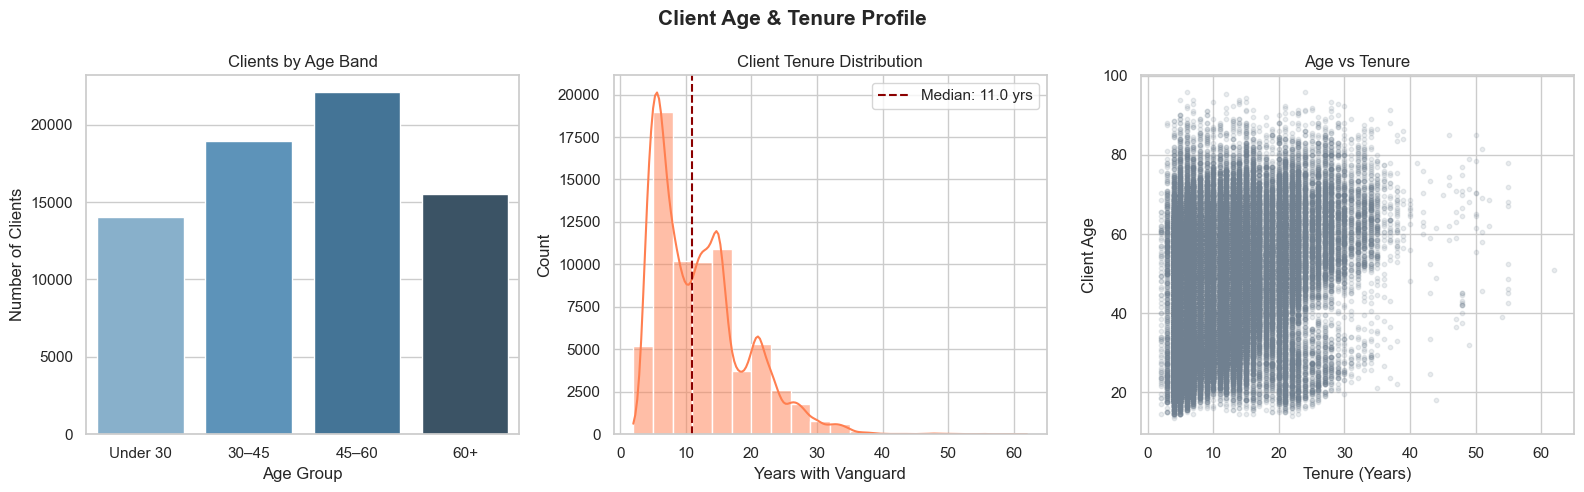

 AGE & TENURE SUMMARY 
Median Tenure:  11.0 years
Mean Tenure:    12.1 years

Age band breakdown:
age_band
Under 30    19.9
30–45       26.9
45–60       31.3
60+         22.0
Name: proportion, dtype: float64


In [68]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs("../visualizations", exist_ok=True)

# Age Bands
df["age_band"] = pd.cut(
    df["age"],
    bins=[0, 30, 45, 60, 100],
    labels=["Under 30", "30–45", "45–60", "60+"]
)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Client Age & Tenure Profile", fontsize=15, fontweight="bold")

# Age bands bar chart
age_band_counts = df["age_band"].value_counts().sort_index()
sns.barplot(
    x=age_band_counts.index,
    y=age_band_counts.values,
    ax=axes[0],
    palette="Blues_d"
)
axes[0].set_title("Clients by Age Band")
axes[0].set_xlabel("Age Group")
axes[0].set_ylabel("Number of Clients")

# Tenure distribution
sns.histplot(
    df["tenure_years"].dropna(),
    bins=20,
    kde=True,
    ax=axes[1],
    color="coral"
)
axes[1].set_title("Client Tenure Distribution")
axes[1].set_xlabel("Years with Vanguard")
axes[1].axvline(
    df["tenure_years"].median(),
    color="darkred",
    linestyle="--",
    label=f"Median: {df['tenure_years'].median():.1f} yrs"
)
axes[1].legend()

# Age vs Tenure scatter
axes[2].scatter(
    df["tenure_years"],
    df["age"],
    alpha=0.15,
    color="slategray",
    s=10
)
axes[2].set_title("Age vs Tenure")
axes[2].set_xlabel("Tenure (Years)")
axes[2].set_ylabel("Client Age")

plt.tight_layout()
plt.savefig("../visualizations/age_tenure_profile.png", dpi=150, bbox_inches="tight")
plt.show()

# Key Numbers
print(" AGE & TENURE SUMMARY ")
print(f"Median Tenure:  {df['tenure_years'].median():.1f} years")
print(f"Mean Tenure:    {df['tenure_years'].mean():.1f} years")
print(f"\nAge band breakdown:\n{df['age_band'].value_counts(normalize=True).mul(100).round(1).sort_index()}")

Valdiation 

In [55]:
df = df.copy()

# Keeping  plausible ages and tenure values
df_valid = df[
    df["age"].between(18, 100) &
    df["tenure_years"].between(0, 50)
].copy()

# Flaging  suspicious rows where tenure exceeds age - 18
df_valid["suspicious"] = df_valid["tenure_years"] > (df_valid["age"] - 18)

print("Suspicious rows:", df_valid["suspicious"].sum())
print(df_valid.loc[df_valid["suspicious"], ["age", "tenure_years"]].head())

Suspicious rows: 8400
     age  tenure_years
19  25.5           8.0
24  30.0          13.0
44  38.0          21.0
57  27.5          13.0
74  19.0          11.0


Higlighting point that are suspicous 

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

sns.scatterplot(
    data=df_valid[~df_valid["suspicious"]],
    x="tenure_years",
    y="age",
    alpha=0.15,
    s=18,
    color="slategray",
    ax=ax
)

sns.scatterplot(
    data=df_valid[df_valid["suspicious"]],
    x="tenure_years",
    y="age",
    s=35,
    color="red",
    ax=ax,
    label="Suspicious"
)

ax.set_title("Age vs Tenure")
ax.set_xlabel("Tenure (Years)")
ax.set_ylabel("Client Age")
ax.legend()

plt.tight_layout()
plt.show()

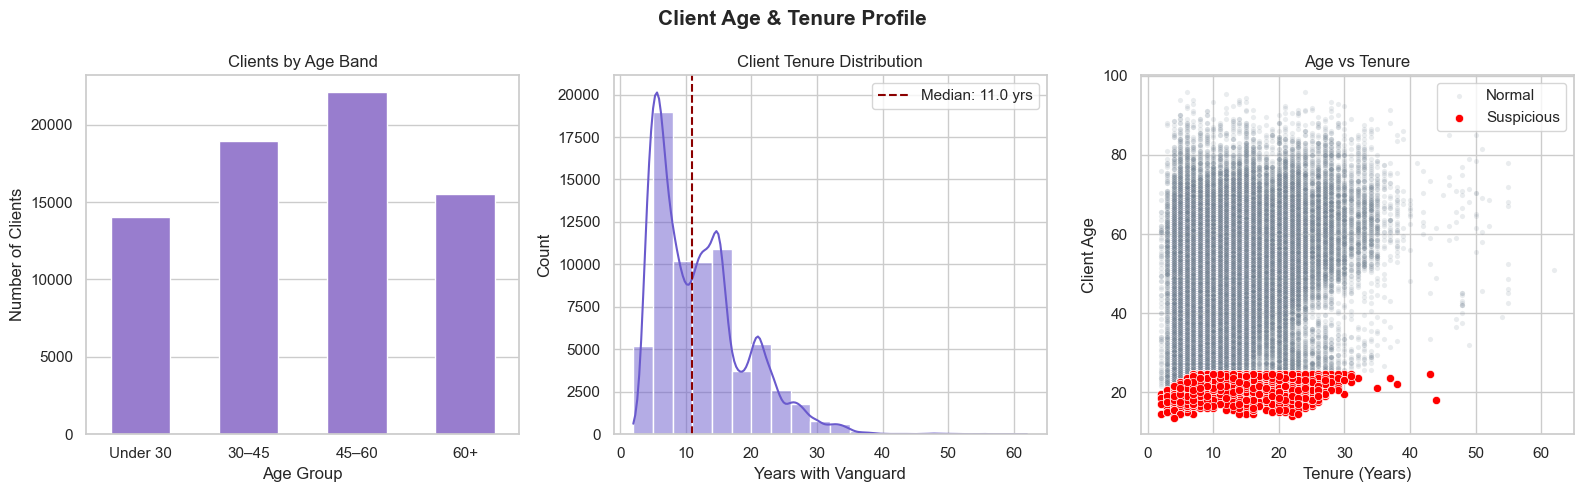

 AGE & TENURE SUMMARY 
Median Tenure: 11.0 years
Mean Tenure:   12.1 years

Suspicious rows: 4631

Age band breakdown:
age_band
Under 30    19.9
30–45       26.9
45–60       31.3
60+         22.0
Name: proportion, dtype: float64


In [67]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs("../visualizations", exist_ok=True)

df = df.copy()
df_clean = df[
    df["age"].between(18, 100) &
    df["tenure_years"].between(0, 50) &
    (df["tenure_years"] <= df["age"] - 18)
].copy()

df["age_band"] = pd.cut(
    df["age"],
    bins=[0, 30, 45, 60, 100],
    labels=["Under 30", "30–45", "45–60", "60+"]
)

df["suspicious_age_tenure"] = (
    df["age"].notna() &
    df["tenure_years"].notna() &
    (df["age"] < 25) &
    (df["tenure_years"] > df["age"] - 18)
)

valid = df[df["tenure_years"].notna() & df["age"].notna()]
normal = valid[~valid["suspicious_age_tenure"]]
suspicious = valid[valid["suspicious_age_tenure"]]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Client Age & Tenure Profile", fontsize=15, fontweight="bold")

age_band_counts = df["age_band"].value_counts().sort_index()
sns.barplot(
    x=age_band_counts.index,
    y=age_band_counts.values,
    ax=axes[0],
    color="mediumpurple",
    width=0.55
)
axes[0].set_title("Clients by Age Band")
axes[0].set_xlabel("Age Group")
axes[0].set_ylabel("Number of Clients")

sns.histplot(
    df["tenure_years"].dropna(),
    bins=20,
    kde=True,
    ax=axes[1],
    color="slateblue"
)
axes[1].set_title("Client Tenure Distribution")
axes[1].set_xlabel("Years with Vanguard")
axes[1].set_ylabel("Count")
axes[1].axvline(
    df["tenure_years"].median(),
    color="darkred",
    linestyle="--",
    label=f"Median: {df['tenure_years'].median():.1f} yrs"
)
axes[1].legend()

sns.scatterplot(
    data=normal,
    x="tenure_years",
    y="age",
    alpha=0.15,
    s=14,
    color="slategray",
    ax=axes[2],
    label="Normal"
)
sns.scatterplot(
    data=suspicious,
    x="tenure_years",
    y="age",
    s=35,
    color="red",
    ax=axes[2],
    label="Suspicious"
)
axes[2].set_title("Age vs Tenure")
axes[2].set_xlabel("Tenure (Years)")
axes[2].set_ylabel("Client Age")
axes[2].legend()

plt.tight_layout()
plt.savefig("../visualizations/age_tenure_profile.png", dpi=150, bbox_inches="tight")
plt.show()

print(" AGE & TENURE SUMMARY ")
print(f"Median Tenure: {df['tenure_years'].median():.1f} years")
print(f"Mean Tenure:   {df['tenure_years'].mean():.1f} years")
print(f"\nSuspicious rows: {df['suspicious_age_tenure'].sum()}")
print(f"\nAge band breakdown:\n{df['age_band'].value_counts(normalize=True).mul(100).round(1).sort_index()}")

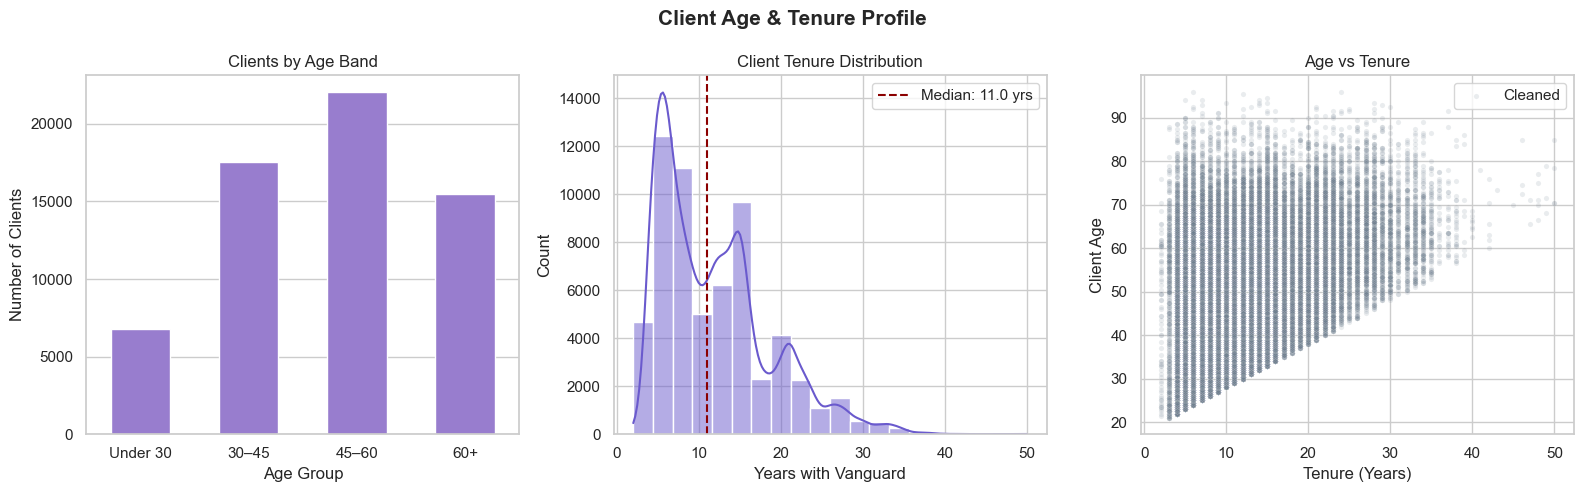

 AGE & TENURE SUMMARY 
Median Tenure: 11.0 years
Mean Tenure:   11.9 years

Suspicious rows removed: 4631

Age band breakdown:
age_band
Under 30    11.0
30–45       28.3
45–60       35.6
60+         25.1
Name: proportion, dtype: float64


In [66]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs("../visualizations", exist_ok=True)

df = df.copy()

df["age_band"] = pd.cut(
    df["age"],
    bins=[0, 30, 45, 60, 100],
    labels=["Under 30", "30–45", "45–60", "60+"]
)

df["suspicious_age_tenure"] = (
    df["age"].notna() &
    df["tenure_years"].notna() &
    (df["age"] < 25) &
    (df["tenure_years"] > df["age"] - 18)
)

df_clean = df[
    df["age"].between(18, 100) &
    df["tenure_years"].between(0, 50) &
    (df["tenure_years"] <= df["age"] - 18)
].copy()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Client Age & Tenure Profile", fontsize=15, fontweight="bold")

age_band_counts = df_clean["age_band"].value_counts().sort_index()
sns.barplot(
    x=age_band_counts.index,
    y=age_band_counts.values,
    ax=axes[0],
    color="mediumpurple",
    width=0.55
)
axes[0].set_title("Clients by Age Band")
axes[0].set_xlabel("Age Group")
axes[0].set_ylabel("Number of Clients")

sns.histplot(
    df_clean["tenure_years"].dropna(),
    bins=20,
    kde=True,
    ax=axes[1],
    color="slateblue"
)
axes[1].set_title("Client Tenure Distribution")
axes[1].set_xlabel("Years with Vanguard")
axes[1].set_ylabel("Count")
axes[1].axvline(
    df_clean["tenure_years"].median(),
    color="darkred",
    linestyle="--",
    label=f"Median: {df_clean['tenure_years'].median():.1f} yrs"
)
axes[1].legend()

sns.scatterplot(
    data=df_clean,
    x="tenure_years",
    y="age",
    alpha=0.15,
    s=14,
    color="slategray",
    ax=axes[2],
    label="Cleaned"
)
axes[2].set_title("Age vs Tenure")
axes[2].set_xlabel("Tenure (Years)")
axes[2].set_ylabel("Client Age")
axes[2].legend()

plt.tight_layout()
plt.savefig("../visualizations/age_tenure_profile.png", dpi=150, bbox_inches="tight")
plt.show()

print(" AGE & TENURE SUMMARY ")
print(f"Median Tenure: {df_clean['tenure_years'].median():.1f} years")
print(f"Mean Tenure:   {df_clean['tenure_years'].mean():.1f} years")
print(f"\nSuspicious rows removed: {df['suspicious_age_tenure'].sum()}")
print(f"\nAge band breakdown:\n{df_clean['age_band'].value_counts(normalize=True).mul(100).round(1).sort_index()}")

CLIENT BEHAVIOUR ANALYSIS


Process Step Drop-off Funnel : Defining  correct step order

C:\Users\Desmond\AppData\Local\Temp\ipykernel_10652\3771934682.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Desmond\AppData\Local\Temp\ipykernel_10652\3771934682.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


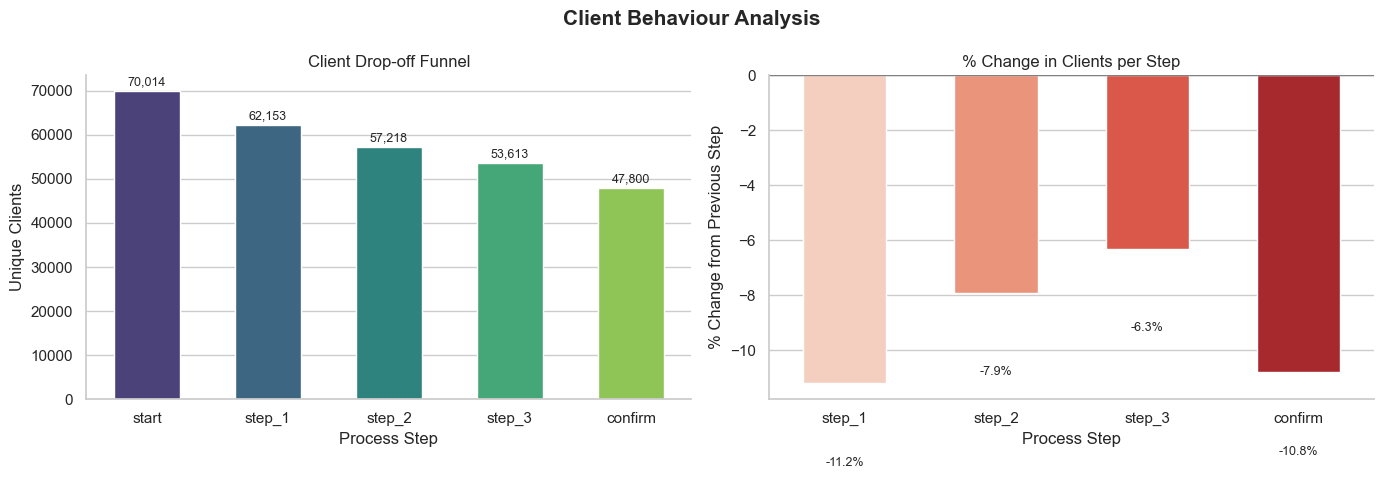

In [81]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

step_order = ["start", "step_1", "step_2", "step_3", "confirm"]

funnel_counts = (
    web.groupby("process_step")["client_id"]
    .nunique()
    .reindex(step_order)
)

drop_off = funnel_counts.pct_change().mul(100).round(1)

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Client Behaviour Analysis", fontsize=15, fontweight="bold")

funnel_palette = sns.color_palette("viridis", len(funnel_counts))
drop_palette = sns.color_palette("Reds", len(drop_off.dropna()))

sns.barplot(
    x=funnel_counts.index,
    y=funnel_counts.values,
    ax=axes[0],
    palette=funnel_palette,
    edgecolor="white",
    linewidth=1,
    width=0.55
)

axes[0].set_title("Client Drop-off Funnel")
axes[0].set_xlabel("Process Step")
axes[0].set_ylabel("Unique Clients")

for i, v in enumerate(funnel_counts.values):
    axes[0].text(i, v + max(funnel_counts.values) * 0.02, f"{int(v):,}", ha="center", fontsize=9)

sns.barplot(
    x=drop_off.index[1:],
    y=drop_off.values[1:],
    ax=axes[1],
    palette=drop_palette,
    edgecolor="white",
    linewidth=1,
    width=0.55
)

axes[1].axhline(0, color="gray", linewidth=1)
axes[1].set_title("% Change in Clients per Step")
axes[1].set_xlabel("Process Step")
axes[1].set_ylabel("% Change from Previous Step")

for i, v in enumerate(drop_off.values[1:]):
    axes[1].text(i, v + (1 if v >= 0 else -3), f"{v:.1f}%", ha="center", fontsize=9)

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("../visualizations/client_behaviour_funnel.png", dpi=150, bbox_inches="tight")
plt.show()

Engagement vs Completion

In [37]:
print(df.columns)
print(web.columns)

Index(['client_id', 'tenure_years', 'tenure_months', 'age', 'gender',
       'num_accts', 'balance', 'calls_last_6_months', 'logons_last_6_months',
       'group_test', 'age_band'],
      dtype='str')
Index(['client_id', 'visitor_id', 'visit_id', 'process_step', 'date_time',
       'source', 'group_test'],
      dtype='str')


C:\Users\Desmond\AppData\Local\Temp\ipykernel_10652\1261509170.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Desmond\AppData\Local\Temp\ipykernel_10652\1261509170.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


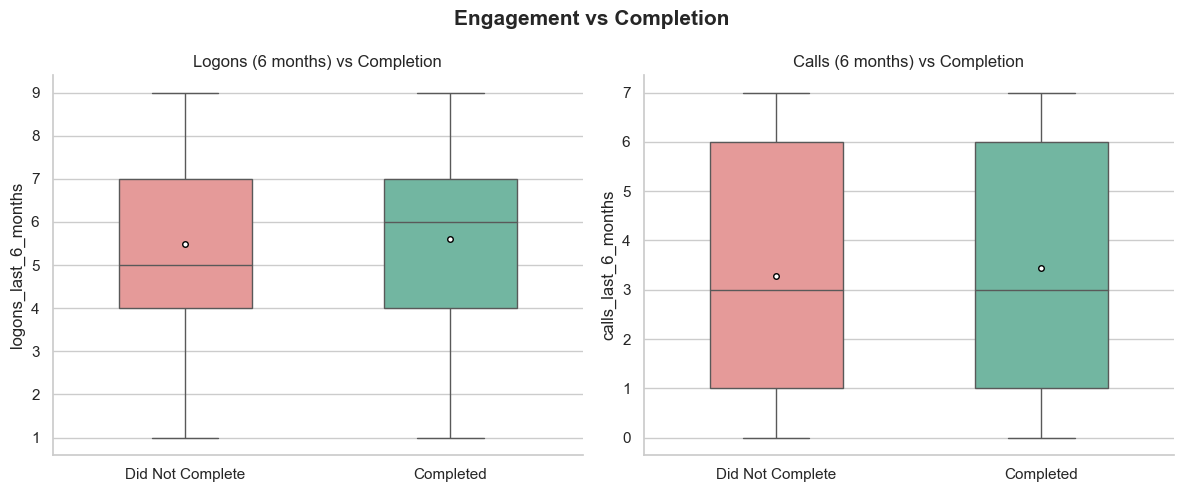

 COMPLETION RATE 
Overall completion rate: 67.7%

Completion by variation:
group_test
control    65.6
test       69.3
Name: completed, dtype: float64


In [82]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs("../visualizations", exist_ok=True)

df = df.copy()
df["completed"] = (
    df["client_id"].isin(web.loc[web["process_step"] == "confirm", "client_id"].unique())
).astype(int)

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Engagement vs Completion", fontsize=15, fontweight="bold")

box_palette = ["#F28E8C", "#66C2A5"]

sns.boxplot(
    x="completed",
    y="logons_last_6_months",
    data=df,
    ax=axes[0],
    palette=box_palette,
    width=0.5,
    fliersize=2.5,
    linewidth=1,
    showmeans=True,
    meanprops={
        "marker": "o",
        "markerfacecolor": "white",
        "markeredgecolor": "black",
        "markersize": 4
    }
)
axes[0].set_title("Logons (6 months) vs Completion")
axes[0].set_xlabel("")
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["Did Not Complete", "Completed"])

sns.boxplot(
    x="completed",
    y="calls_last_6_months",
    data=df,
    ax=axes[1],
    palette=box_palette,
    width=0.5,
    fliersize=2.5,
    linewidth=1,
    showmeans=True,
    meanprops={
        "marker": "o",
        "markerfacecolor": "white",
        "markeredgecolor": "black",
        "markersize": 4
    }
)
axes[1].set_title("Calls (6 months) vs Completion")
axes[1].set_xlabel("")
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["Did Not Complete", "Completed"])

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("../visualizations/engagement_vs_completion.png", dpi=150, bbox_inches="tight")
plt.show()

print(" COMPLETION RATE ")
print(f"Overall completion rate: {df['completed'].mean() * 100:.1f}%")
print(f"\nCompletion by variation:\n{df.groupby('group_test')['completed'].mean().mul(100).round(1)}")

Key Findings 

Who are the primary clients using this online process?

The typical Vanguard client is **middle-aged (median 47 years)**, holds **2 accounts**,
and carries a **median balance of $63,333**. Gender is approximately evenly split.
This profile suggests an established, mid-career investor.

Are the primary clients younger or older, new or long-standing?

The largest client segment is **45–60 years old (31.3%)**.
Over **53% of clients are aged 45 or above**.
The median tenure is **11 years**, confirming these are predominantly
**long-standing, loyal clients** — not new users.

Does the new design make business sense ?

The Test group completed the process at **69.3%** vs **65.6%** for Control
a **+3.7 percentage point uplift**. 